<div align="center">
  <h3><b>ESCUELA POLITÉCNICA NACIONAL</b></h3>
  <h3><b>FACULTAD DE INGENIERÍA EN SISTEMAS</b></h3>
  <h3><b>INGENIERÍA EN CIENCIAS DE LA COMPUTACIÓN</b></h3>
  <h3><b>RECUPERACIÓN DE LA INFORMACIÓN</b></h3>
</div>

---
**Nombre**   Mark Hernández        
**Fecha**    13/05/26  
**Docente**  Iván Carrera

# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


Para cargar el corpus primero tenemos que cargar el archivo csv.

### Carga del archivo csv


Ejemplo de carga desde el archivo local.

In [1]:
import pandas as pd 
import os

path ="..\\05ev\\data"
files = os.listdir(path)
path_csv  = os.path.join(path, files[0])
df = pd.read_csv(path_csv)

documents =df['text'].astype(str).tolist()

# IDs de los documentos
doc_ids = [f"Document_{i}" for i in range(len(documents))]

print(f"Documentos cargados: {len(documents)}")

Documentos cargados: 10859


Ejemplo de carga del corpus desde un link web.

In [2]:
import pandas as pd
import os
import kagglehub

# 1. Carga del corpus (Wikipedia Text Corpus)
path = kagglehub.dataset_download("gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects")

# Buscamos el archivo CSV
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
path_csv = os.path.join(path, csv_file)

df = pd.read_csv(path_csv)

documents =df['text'].astype(str).tolist()

# IDs de los documentos
doc_ids = [f"Document_{i}" for i in range(len(documents))]

print(f"Documentos cargados: {len(documents)}")

c:\Users\mark_\Documents\ir26a\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Documentos cargados: 10859


Verificamos que el dataframe posea los documentos con sus respectivos contenidos sin limpiar

In [3]:
df = pd.DataFrame({'doc_id': doc_ids, 'text': documents})
df.head()

,doc_id,text
0,Document_0,Anovo\n\nAnovo (formerly A Novo) is a computer...
1,Document_1,Battery indicator\n\nA battery indicator (also...
2,Document_2,"Bob Pease\n\nRobert Allen Pease (August 22, 19..."
3,Document_3,CAVNET\n\nCAVNET was a secure military forum w...
4,Document_4,CLidar\n\nThe CLidar is a scientific instrumen...


Luego de cargar el corpus nos dedicamos al preprocesamiento y limpieza del contenido de nuestro corpus. Primero descargamos los recursos necesarios.

In [4]:
import nltk
import re

# Descargar recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mark_\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mark_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Posterior a ello, creamos la función que usaremos para la limpieza del corpus.

In [5]:
# Inicialización de herramientas
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    if not isinstance(text, str):
        return ""
    # Limpieza básica
    text_clean = re.sub(r"[^a-zA-Z0-9\s]", '', text.lower())
    # Tokenización y filtrado
    tokens = word_tokenize(text_clean)
    tokens = [t for t in tokens if t not in stop_words]
    filtered = [stemmer.stem(w) for w in tokens]
    return " ".join(filtered)

Aplicamos la función creada al contenido de cada libro en el dataframe.

In [6]:
# Aplicar al dataframe
df['clean_text'] = df['text'].apply(preprocess)

Mostramos los 5 primeros documentos

In [7]:
df.head(5)

,doc_id,text,clean_text
0,Document_0,Anovo\n\nAnovo (formerly A Novo) is a computer...,anovo anovo formerli novo comput servic compan...
1,Document_1,Battery indicator\n\nA battery indicator (also...,batteri indic batteri indic also known batteri...
2,Document_2,"Bob Pease\n\nRobert Allen Pease (August 22, 19...",bob peas robert allen peas august 22 1940 june...
3,Document_3,CAVNET\n\nCAVNET was a secure military forum w...,cavnet cavnet secur militari forum becam oper ...
4,Document_4,CLidar\n\nThe CLidar is a scientific instrumen...,clidar clidar scientif instrument use measur p...


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import time

# 3. Representación Vectorial
vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8)
start_time = time.time()
print("Calculando matriz TF-IDF para el corpus...")
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])

elapsed = time.time() - start_time
print(f"✓ Matriz calculada en {elapsed:.2f} segundos")
print(f"\nDimensiones de la matriz TF-IDF:")
print(f"  → {tfidf_matrix.shape[0]} documentos  x  {tfidf_matrix.shape[1]} términos únicos")
print(f"\nTamaño en memoria (sparse): {tfidf_matrix.data.nbytes / 1024 / 1024:.2f} MB")
print(f"Elementos no cero: {tfidf_matrix.nnz:,}")

Calculando matriz TF-IDF para el corpus...
✓ Matriz calculada en 3.29 segundos

Dimensiones de la matriz TF-IDF:
  → 10859 documentos  x  5000 términos únicos

Tamaño en memoria (sparse): 14.82 MB
Elementos no cero: 1,942,808


Mostramos la matriz para los primeros 10 documentos.

In [9]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head(10)

,01,05,10,100,1000,10000,100000,11,110,12,...,yield,york,young,younger,youth,youtub,zealand,zero,zinc,zone
0,0.000000,0.0,0.135428,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025707
2,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.000000,0.0,0.000000,0.044614,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
5,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
6,0.000000,0.0,0.015445,0.016739,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
7,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
8,0.000000,0.0,0.021343,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
9,0.015848,0.0,0.017190,0.009314,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


Creamos una función que nos permita devolver un fragmento de donde se encuentra la query en el documento

In [10]:
def get_snippet(text, query, window=100):
    """Busca la primera coincidencia de la query y devuelve un fragmento."""
    query_terms = query.lower().split()
    text_lower = text.lower()
    
    # Buscamos la posición del primer término de la query que aparezca
    pos = -1
    for term in query_terms:
        pos = text_lower.find(term)
        if pos != -1: break
        
    if pos == -1: return text[:window*2] + "..." # Si no hay match exacto, inicio del texto
    
    start = max(0, pos - window)
    end = min(len(text), pos + window)
    return f"...{text[start:end]}..."

Luego procedemos a crear la función de consulta y realizar las consultas.

In [11]:
# 4. Verificación con 10 queries
queries = ["science and technology",
            "history of ancient civilizations",
            "literature and art", 
           "mathematics and physics",
            "biological systems",
            "geography and culture",
            "political systems",
            "philosophy and ethics",
            "economics and trade",
            "nature and environment"
           ] 

def search_tfidf(query, i, top_n=5):
    query_clean = preprocess(query)
    query_vec = vectorizer.transform([query_clean])
    df[f'similarity {i}'] = cosine_similarity( tfidf_matrix, query_vec).flatten()
    results = df.sort_values(by=f'similarity {i}', ascending=False).head(top_n).copy()
    results['fragmento'] = results['text'].apply(lambda x: get_snippet(x, query))
    return results[[ 'doc_id','fragmento',f'similarity {i}']]

In [12]:
# Diccionario para guardar resultados si deseas compararlos después
all_results = {}

print(f"{'Query':<30} | {'Top Doc Index':<15} | {'Similitud':<10}")
print("-" * 60)

for i, q in enumerate(queries):
    res = search_tfidf(q, i, top_n=3) # Queremos ver solo los top 3 resultados para cada query
    all_results[q] = res
    
    # Imprimir resumen de verificación rápida
    if not res.empty:
        top_idx = res.index[0]
        top_sim = res.iloc[0][f'similarity {i}']
        print(f"{q[:30]:<30} | {top_idx:<15} | {top_sim:.4f}")

# Ejemplo: Ver detalle de la primera query
print("\nDetalle de la primera query:")
display(all_results[queries[0]])

# Ejemplo: Ver detalle de la última query
print("\nDetalle de la última query:")
display(all_results[queries[-1]])

Query                          | Top Doc Index   | Similitud 
------------------------------------------------------------
science and technology         | 618             | 0.6559
history of ancient civilizatio | 2186            | 0.3580
literature and art             | 5475            | 0.4907
mathematics and physics        | 1734            | 0.5248
biological systems             | 5592            | 0.5133
geography and culture          | 6032            | 0.7336
political systems              | 4823            | 0.2849
philosophy and ethics          | 9852            | 0.4974
economics and trade            | 2570            | 0.5277
nature and environment         | 8911            | 0.3313

Detalle de la primera query:


,doc_id,fragmento,similarity 0
618,Document_618,...Ministry of Science and Technology (Banglad...,0.655858
3842,Document_3842,...Ministry of Science and Technology (China)\...,0.651464
1317,Document_1317,...Ministry of Science and Technology (Taiwan)...,0.618805



Detalle de la última query:


,doc_id,fragmento,similarity 9
8911,Document_8911,...Ministry of Environment and Energy (Greece)...,0.331289
5440,Document_5440,...Energy and environmental engineering\n\nEne...,0.312072
1809,Document_1809,...Intelligent environment\n\nIntelligent Envi...,0.305729


Mostramos el dataframe con la similaridad acorde a cada query para todos los documentos. Es fácil evidenciar que en la mayoría son ceros pues las queries no poseen similitud con dichos documentos.

In [13]:
df

,doc_id,text,clean_text,similarity 0,similarity 1,similarity 2,similarity 3,similarity 4,similarity 5,similarity 6,similarity 7,similarity 8,similarity 9
0,Document_0,Anovo\n\nAnovo (formerly A Novo) is a computer...,anovo anovo formerli novo comput servic compan...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
1,Document_1,Battery indicator\n\nA battery indicator (also...,batteri indic batteri indic also known batteri...,0.000000,0.0,0.0,0.000000,0.020970,0.0,0.020416,0.0,0.0,0.000000
2,Document_2,"Bob Pease\n\nRobert Allen Pease (August 22, 19...",bob peas robert allen peas august 22 1940 june...,0.073592,0.0,0.0,0.000000,0.011002,0.0,0.010711,0.0,0.0,0.000000
3,Document_3,CAVNET\n\nCAVNET was a secure military forum w...,cavnet cavnet secur militari forum becam oper ...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
4,Document_4,CLidar\n\nThe CLidar is a scientific instrumen...,clidar clidar scientif instrument use measur p...,0.000000,0.0,0.0,0.024488,0.000000,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10854,Document_10854,Soundcast\n\nSoundcast LLC is a privately fund...,soundcast soundcast llc privat fund compani cr...,0.055481,0.0,0.0,0.012045,0.079497,0.0,0.077397,0.0,0.0,0.000000
10855,Document_10855,Spectrum analyzer\n\nA spectrum analyzer measu...,spectrum analyz spectrum analyz measur magnitu...,0.000000,0.0,0.0,0.000000,0.002299,0.0,0.002238,0.0,0.0,0.006694
10856,Document_10856,Telepresence technology\n\nTelepresence techno...,telepres technolog telepres technolog term use...,0.163438,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.078498
10857,Document_10857,Trans-Pacific Profiler Network\n\nThe Trans-Pa...,transpacif profil network transpacif profil ne...,0.000000,0.0,0.0,0.000000,0.023017,0.0,0.022409,0.0,0.0,0.000000


## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

Para el apartado 5 usaremos la librería rank_bm25 para crear el sistema de recuperación usando el modelo BM25

In [14]:
# 5. Implementación del sistema de recuperación usando BM25
from rank_bm25 import BM25Okapi
import time

print("Preparando el corpus para BM25...")
start_time = time.time()

# BM25Okapi requiere que el corpus esté tokenizado (una lista de listas de palabras)
tokenized_corpus = [str(doc).split() for doc in df['clean_text']]

# Inicializamos el modelo
bm25 = BM25Okapi(tokenized_corpus)

elapsed = time.time() - start_time
print(f"✓ Modelo BM25 inicializado en {elapsed:.2f} segundos\n")

Preparando el corpus para BM25...
✓ Modelo BM25 inicializado en 1.95 segundos



Creamos una función de búsqueda para el modelo BM25:

In [15]:

def search_bm25(query, i, top_n=5):
    """Realiza una búsqueda utilizando el modelo BM25."""
    query_clean = preprocess(query)
    tokenized_query = query_clean.split()
    
    # Obtener los scores de BM25 para la query
    doc_scores = bm25.get_scores(tokenized_query)
    
    # Asignar scores temporalmente para ordenar
    df[f'bm25_score {i}'] = doc_scores
    
    # Extraer los mejores resultados
    results = df.sort_values(by=f'bm25_score {i}', ascending=False).head(top_n).copy()
    results['fragmento'] = results['text'].apply(lambda x: get_snippet(x, query))
    
    return results[['doc_id', 'fragmento', f'bm25_score {i}']]



Y verificamos como funciona nuestra función de búsqueda para las 10 queries anteriores

In [16]:
# 6. Verificación con las mismas 10 queries
all_results_bm25 = {}

print(f"{'Query':<30} | {'Top Doc Index':<15} | {'Score BM25':<10}")
print("-" * 65)

for i, q in enumerate(queries):
    res_bm25 = search_bm25(q, i, top_n=3)
    all_results_bm25[q] = res_bm25
    
    # Imprimir resumen rápido
    if not res_bm25.empty:
        top_idx = res_bm25.index[0]
        top_score = res_bm25.iloc[0][f'bm25_score {i}']
        print(f"{q[:30]:<30} | {top_idx:<15} | {top_score:.4f}")

# Mostrar el detalle de la primera query para confirmar
print("\nDetalle de la primera query con BM25:")
display(all_results_bm25[queries[0]])

# Ejemplo: Ver detalle de la última query
print("\nDetalle de la última query con BM25:")
display(all_results_bm25[queries[-1]])

Query                          | Top Doc Index   | Score BM25
-----------------------------------------------------------------
science and technology         | 5501            | 6.0734
history of ancient civilizatio | 8776            | 15.2221
literature and art             | 9207            | 11.2847
mathematics and physics        | 3757            | 10.2004
biological systems             | 5592            | 7.6234
geography and culture          | 10074           | 11.9091
political systems              | 4823            | 7.6651
philosophy and ethics          | 6579            | 16.3631
economics and trade            | 4910            | 10.7395
nature and environment         | 1349            | 7.5913

Detalle de la primera query con BM25:


,doc_id,fragmento,bm25_score 0
5501,Document_5501,...Ministry of Science and Technology (Pakista...,6.073362
1317,Document_1317,...Ministry of Science and Technology (Taiwan)...,5.976910
6377,Document_6377,...Department of Science and Technology (Phili...,5.975379



Detalle de la última query con BM25:


,doc_id,fragmento,bm25_score 9
1349,Document_1349,"...Federal Ministry of the Environment, Nature...",7.591269
7140,Document_7140,...ate() is an ecological environment green go...,7.387720
6290,Document_6290,...onal Centre for Earth Observation (NCEO) is...,7.173637


## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 

In [17]:
# 7. Comparación de documentos recuperados por TF-IDF y BM25
print("Comparación de Top 3 Documentos: TF-IDF vs BM25\n")

for i, q in enumerate(queries):
    print(f"Query {i+1}: '{q}'")
    print("-" * 75)
    
    # Reiniciamos los índices para alinear los DataFrames por posición (Rank)
    res_tfidf = all_results[q].reset_index()
    res_bm25 = all_results_bm25[q].reset_index()
    
    # Armamos un DataFrame comparativo lado a lado
    comparison_df = pd.DataFrame({
        'Rank': [1, 2, 3],
        'Doc TF-IDF': res_tfidf['doc_id'],
        'Score TF-IDF': res_tfidf[f'similarity {i}'].round(4),
        'Doc BM25': res_bm25['doc_id'],
        'Score BM25': res_bm25[f'bm25_score {i}'].round(4)
    })
    
    # Resaltamos si ambos modelos trajeron exactamente el mismo documento en el Top 3
    # (Independiente del orden exacto)
    docs_tfidf = set(res_tfidf['doc_id'])
    docs_bm25 = set(res_bm25['doc_id'])
    docs_en_comun = docs_tfidf.intersection(docs_bm25)
    
    display(comparison_df.style.hide(axis="index"))
    print(f"Documentos en común en el Top 3: {len(docs_en_comun)}")
    print("\n")

Comparación de Top 3 Documentos: TF-IDF vs BM25

Query 1: 'science and technology'
---------------------------------------------------------------------------


Rank,Doc TF-IDF,Score TF-IDF,Doc BM25,Score BM25
1,Document_618,0.655900,Document_5501,6.073400
2,Document_3842,0.651500,Document_1317,5.976900
3,Document_1317,0.618800,Document_6377,5.975400


Documentos en común en el Top 3: 1


Query 2: 'history of ancient civilizations'
---------------------------------------------------------------------------


Rank,Doc TF-IDF,Score TF-IDF,Doc BM25,Score BM25
1,Document_2186,0.358000,Document_8776,15.222100
2,Document_2332,0.333500,Document_4265,14.255200
3,Document_1884,0.299900,Document_3359,14.037300


Documentos en común en el Top 3: 0


Query 3: 'literature and art'
---------------------------------------------------------------------------


...

Documentos en común en el Top 3: 1


Query 9: 'economics and trade'
---------------------------------------------------------------------------


Rank,Doc TF-IDF,Score TF-IDF,Doc BM25,Score BM25
1,Document_2570,0.527700,Document_4910,10.739500
2,Document_1004,0.517700,Document_5738,10.197900
3,Document_108,0.424900,Document_6354,9.341300


Documentos en común en el Top 3: 0


Query 10: 'nature and environment'
---------------------------------------------------------------------------


Rank,Doc TF-IDF,Score TF-IDF,Doc BM25,Score BM25
1,Document_8911,0.331300,Document_1349,7.591300
2,Document_5440,0.312100,Document_7140,7.387700
3,Document_1809,0.305700,Document_6290,7.173600


Documentos en común en el Top 3: 0




### Análisis de la Comparación: TF-IDF vs BM25

El gráfico inferior ilustra el nivel de solapamiento (documentos en común) en el **Top 3** de resultados entre el modelo TF-IDF y el modelo BM25 para nuestras 10 consultas.

Es común observar que los modelos no recuperan exactamente los mismos documentos ni en el mismo orden. Esto se debe a las diferencias matemáticas en cómo calculan la relevancia:

1. **Saturación de la Frecuencia (TF):** En TF-IDF, si una palabra de búsqueda aparece 50 veces en un documento, su peso es significativamente mayor que si aparece 10 veces. **BM25**, por el contrario, aplica una curva de *saturación*. Asume que después de ciertas repeticiones, la palabra ya demostró que el documento trata sobre ese tema, limitando el puntaje para que una sola palabra repetida excesivamente no domine el resultado.
2. **Normalización por Longitud:** **BM25** penaliza de forma inteligente a los documentos excesivamente largos. En TF-IDF clásico, un documento gigante tiene más probabilidad de contener las palabras de búsqueda simplemente por su tamaño. BM25 equilibra esto comparando la longitud del documento con la longitud promedio del corpus.

**Conclusión:** Aunque TF-IDF es un excelente punto de partida para entender la recuperación de información, **BM25** es el estándar de la industria (utilizado por motores como Elasticsearch o Lucene) porque ofrece resultados más robustos frente a variaciones extremas en la longitud de los textos y la repetición de palabras.

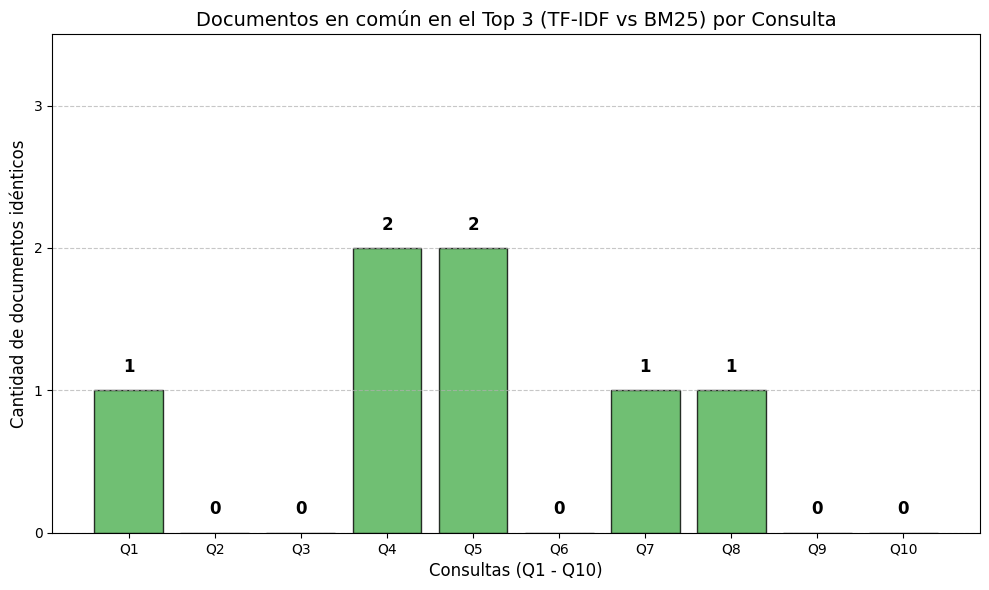

In [18]:
import matplotlib.pyplot as plt

# Extraer el número de documentos en común para cada query
overlap_counts = []
query_labels = []

for i, q in enumerate(queries):
    docs_tfidf = set(all_results[q]['doc_id'].head(3))
    docs_bm25 = set(all_results_bm25[q]['doc_id'].head(3))
    overlap = len(docs_tfidf.intersection(docs_bm25))
    overlap_counts.append(overlap)
    # Usaremos etiquetas cortas como Q1, Q2, etc., para que el gráfico sea legible
    query_labels.append(f"Q{i+1}")

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bars = plt.bar(query_labels, overlap_counts, color='#4CAF50', edgecolor='black', alpha=0.8)

# Personalizar el gráfico
plt.title('Documentos en común en el Top 3 (TF-IDF vs BM25) por Consulta', fontsize=14)
plt.xlabel('Consultas (Q1 - Q10)', fontsize=12)
plt.ylabel('Cantidad de documentos idénticos', fontsize=12)
plt.yticks([0, 1, 2, 3]) # El máximo posible es 3 porque comparamos el Top 3
plt.ylim(0, 3.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir los valores exactos sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()